# PROJECT CARD

**The paper:** Ke, Ong, Shih, Yin (2012). Three-Dimensional Structures Self-Assembled from DNA Bricks

**The data object:** 6H x 10H x 128B cuboid structure assembly yields at seven different $MgCl_2$ concentrations

**The random variable chosen:** assembly yield (%) as a function of the $MgCl_2$ concentration (mM) -> Y | [$MgCL_2$]

**What the paper does:**  The paper demonstrates a self-assembly of DNA bricks which represent 3D DNA nanostructures. One part of the study shows that assembly yields depend on the annealing conditions with and optimal yield at 40 mM $MgCl_2$. Higher and lower concentrations reduce yield. 

**The generative model proposed:** Gaussian Model
$$\mu_y(x)=A\exp[-\frac{(x-\mu)^2}{2\omega^2}]$$

**Parameters and assumptions:**
1. The model assumption is a Gaussian model with noramally distributed errors. 
2. [$MgCl_2$] is expected to influence yield
3. There is an optimal concentration where yield is highest. 

$A$: max. yield [%]

$\mu$: optimal $MgCl_2$ concentration [mM]

$\omega$: width oft optimal [mM]

$\sigma$: standard deviation of the experimental error []

**The forward simulation:**
Testing the gaussian model based on chosen parameters to see what curve the simulated data provides us. Theta are chosen and we get a simulated yield. 

**The parameterization/fitting:**
The experimental data is given and the model parameters adjusted to the observed data. Thereafter, a negative log-likelihood approach is used to identify the optimal parameter combination. The evaluation of validity of the model is based on bootstrapping the data given by the paper.  

**What/if the model adds to the paper:**
It provides a simplified mathematical description of the relationship between $MgCl_2$ concentration and assembly yield (obeying the model limitations written below). Therefore, it allows estimation of optimal $MgCl_2$ concentration and prediction of expected yield at $MgCl_2§ concentrations that were not directly measured. 

**Model limitiations/how it breaks:**
1. The general DNA assembly depends on more factors than just the $MgCl_2$ concentration (e.g. temperature, stochiometry, annealing protocol), resulting in the model not being able to predict actual yield under arbitrary experimental conditions. 
2. The model is simplified. The Gaussian curve is symmetric which might not reflect the actual biological relationship of self-assembly and $MgCl_2$ concentration. 
3. The model only describes an empirical relationship rather than the molecular mechanism of DNA Brick self-assembly. 

### Modules/Libraries necessary

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import sys

### Data the paper presents

Experimental Data from Fig. S15:.
   mgcl2_mM  yield_percent
0        20            2.5
1        30            3.7
2        40            3.7
3        50            3.6
4        60            3.0
5        70            2.6
6        80            1.7

Optimal [MgCl₂]: 40 mM
Maximum yield: 3.7%


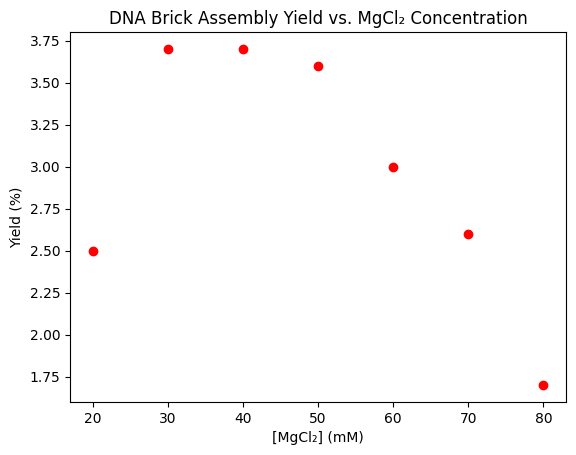

In [12]:
sys.path.append('data')
from data import conc, yield_perc
df_data = pd.DataFrame({'mgcl2_mM': conc, 'yield_percent': yield_perc})

print("Experimental Data from Fig. S15:.")
print(df_data)
print(f"\nOptimal [MgCl₂]: 40 mM")
print(f"Maximum yield: {df_data['yield_percent'].max():.1f}%")

plt.figure()
plt.scatter(df_data['mgcl2_mM'], df_data['yield_percent'], color='red', label='Measured yields')
plt.xlabel('[MgCl₂] (mM)')
plt.ylabel('Yield (%)')
plt.title('DNA Brick Assembly Yield vs. MgCl₂ Concentration')
plt.show()

### Simulation

In [13]:
LCG_A = 1664525
LCG_C = 1013904223
LCG_M = 2 ** 32


def lcg(state, a, c, m):
    state = (a * state + c) % m
    return state


def uniforms_from_lcg(k, seed):
    out = [0.] * k
    state = seed
    for i in range(k):
        state = lcg(state, LCG_A, LCG_C, LCG_M)
        out[i] = state / LCG_M
    return out

def normals_from_lcg(k, seed):
    n_pairs = (k + 1) // 2
    u = uniforms_from_lcg(2 * n_pairs, seed)
    z = []
    for i in range(n_pairs):
        u1 = max(u[2*i], 1e-12)
        u2 = u[2 * i +1]
        r = math.sqrt(-2.0 * math.log(u1))
        z.append(r * math.cos(2 * math.pi * u2))
        z.append(r * math.sin(2.0 * math.pi * u2))
    return z[:k]

#### Model and Forward Simulation

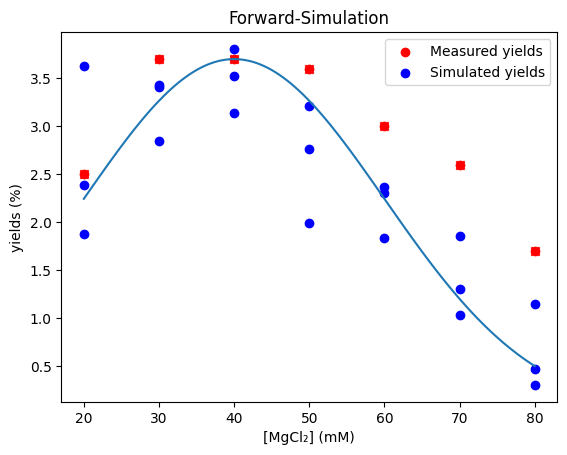

In [14]:
def gaussian(x, A, mu, width):
    return A * math.exp(-((x - mu) ** 2) / (2 * width ** 2))

def simulate_yields(x_values, A, mu, width, sigma, seed):
    z = normals_from_lcg(len(x_values), seed)
    return [gaussian(x, A, mu, width) + sigma * z[i] for i, x in enumerate(x_values)]


A_sim, mu_sim, width_sim, sigma_sim = 3.7, 40, 20, 0.5

n_rep = 3
x_sim = [c for c in conc for _ in range(n_rep)]
y_sim = simulate_yields(x_sim, A_sim, mu_sim, width_sim, sigma_sim, seed=12345)

x_curve = [20 + 0.5 * i for i in range(121)] # ideal curve for plotting

plt.figure()
plt.scatter(df_data['mgcl2_mM'], df_data['yield_percent'], color='red', label='Measured yields')

plt.plot(x_curve, [gaussian(x, A_sim, mu_sim, width_sim) for x in x_curve])
plt.scatter(x_sim, y_sim, color='blue', label='Simulated yields')
plt.scatter(conc, yield_perc, color='red', marker='x')
plt.xlabel('[MgCl₂] (mM)')
plt.ylabel('yields (%)')
plt.title('Forward-Simulation'); plt.legend(); plt.show()
plt.show()

Gaussian Distribution fits the data rather well. Now the optimal parameters need to be discovered.

#### Backward Simulation

In [16]:
def normal(y, mean, sigma):
    density = math.exp(-((y - mean) ** 2) / (2 * sigma ** 2)) / (sigma * math.sqrt(2 * math.pi))
    return max(density, 1e-300)

def nll(x_data, y_data, A, mu, width, sigma):
    total = 0.0
    for i in range(len(x_data)):
        y_predicted = gaussian(x_data[i], A, mu, width)
        total -= math.log(normal(y_data[i], y_predicted, sigma))

    return total


A_range = [2.5 + 0.2 * i for i in range(14)]
mu_range = [20 + 1 * i for i in range(41)]
width_range = [6 + 3 * i for i in range(12)]
sigma_range = [0.05 * i for i in range(1, 13)]

def fit_gaussian(x_data, y_data):
    candidates = []
    scores = []
    for A in A_range:
        for mu in mu_range:
            for width in width_range:
                for sigma in sigma_range:
                    candidates.append((A, mu, width, sigma))
                    scores.append(nll(x_data, y_data, A, mu, width, sigma))
    position = scores.index(min(scores))
    A, mu, width, sigma = candidates[position]
    return A, mu, width, sigma, scores[position]

best_A, best_mu, best_width, best_sigma, best_nll = fit_gaussian(x_sim, y_sim)


print("Best-fit parameters:")
print("A:", best_A)
print("mu:", best_mu, "mM")
print("width:", best_width)
print("sigma:", best_sigma)
print("NLL:", best_nll)

Best-fit parameters:
A: 3.3
mu: 37 mM
width: 24
sigma: 0.45
NLL: 12.599617755573389


### Fit to actual data

Fitted parameters from measured data:
A: 3.7 %
mu: 43 mM
width: 30 mM
sigma: 0.2 %


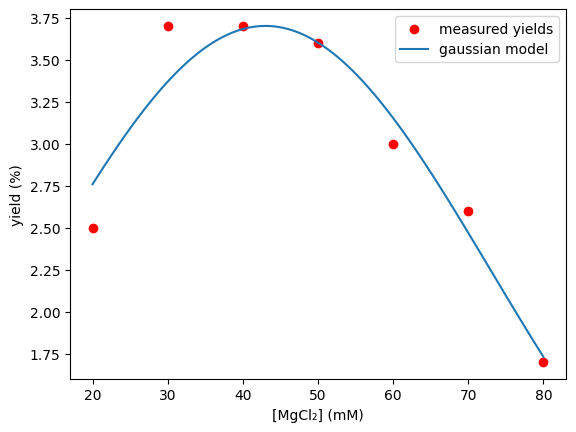

In [17]:
A_fit, mu_fit, width_fit, sigma_fit, nll_fit = fit_gaussian(conc, yield_perc)
print("Fitted parameters from measured data:")
print(f"A: {A_fit} %")
print(f"mu: {mu_fit} mM")
print(f"width: {width_fit} mM")
print(f"sigma: {sigma_fit} %")

plt.figure()
plt.scatter(conc, yield_perc, color='red', label='measured yields')
plt.plot(x_curve, [gaussian(x, A_fit, mu_fit, width_fit) for x in x_curve], label='gaussian model')
plt.xlabel('[MgCl₂] (mM)'); plt.ylabel('yield (%)')
plt.legend(); plt.show()

###  Bootstrap, Validation

Curvature: mu_fit = 43.0 +/- 1.3 mM
Bootstrap: mu_fit = 43.0 +/- 3.3 mM (bootstrap SD)
Bootstrap: sigma_fit = 0.2 +/- 0.1 % (bootstrap SD)


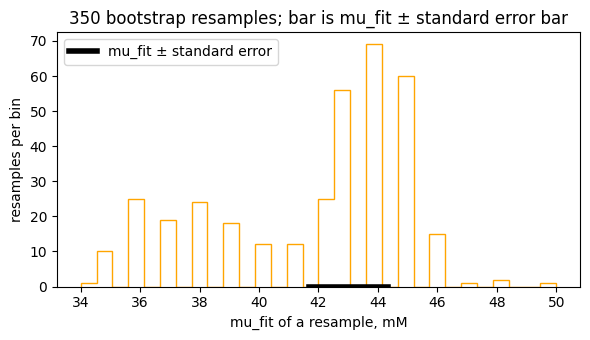

In [18]:
# curvature based uncertainty

h = 0.5
curvature = (nll(conc, yield_perc, A_fit, mu_fit + h, width_fit, sigma_fit) - 2 * nll(conc, yield_perc, A_fit, mu_fit, width_fit, sigma_fit) + nll(conc, yield_perc, A_fit, mu_fit - h, width_fit, sigma_fit)) / h ** 2

sigma_mu = 1 / curvature ** 0.5
print(f"Curvature: mu_fit = {mu_fit:.1f} +/- {sigma_mu:.1f} mM")

# bootstrap 

N = len(conc)
B = 350
rs = uniforms_from_lcg(B * N, seed=8)
equal = [1 / N] * N

boot_mu = [0.0] * B
boot_A = [0.0] * B
boot_width = [0.0] * B
boot_sigma = [0.0] * B


def choose(r, probs):
    running = 0.0
    for k in range(len(probs)):
        running += probs[k]
        if r < running:
            return k
    return len(probs) - 1

for b in range(B):
    conc_resample = [0.0] * N
    yield_resample = [0.0] * N
    for i in range(N):
        j = choose(rs[b*N + i], equal)
        conc_resample[i] = conc[j]
        yield_resample[i] = yield_perc[j]
    boot_A[b], boot_mu[b], boot_width[b], boot_sigma[b], _ = fit_gaussian(conc_resample, yield_resample)

sigma_mu_boot = np.std(boot_mu)
print(f"Bootstrap: mu_fit = {mu_fit:.1f} +/- {sigma_mu_boot:.1f} mM (bootstrap SD)")
print(f"Bootstrap: sigma_fit = {sigma_fit:.1f} +/- {np.std(boot_sigma):.1f} % (bootstrap SD)")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(boot_mu, bins=30, color="orange", histtype="step")
ax.plot([mu_fit - sigma_mu, mu_fit + sigma_mu], [0, 0], color="black", linewidth=4, label="mu_fit ± standard error")
ax.set_xlabel("mu_fit of a resample, mM")
ax.set_ylabel("resamples per bin")
ax.set_title(f"{B} bootstrap resamples; bar is mu_fit ± standard error bar")
ax.legend()
plt.tight_layout()
plt.show()
    

mean of residuals: 0.0061668227001936094
standard deviation of residuals: 0.17634751459233022
sigma_fit: 0.2


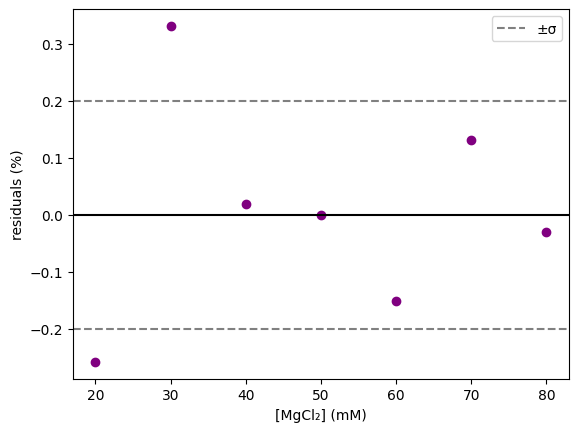

In [19]:
residuals = [y - gaussian(x, A_fit, mu_fit, width_fit) for x, y in zip(conc, yield_perc)]

print(f"mean of residuals: {np.mean(residuals)}")
print(f"standard deviation of residuals: {np.std(residuals)}")
print(f"sigma_fit: {sigma_fit}")

plt.figure()
plt.scatter(conc, residuals, color='purple')
plt.axhline(0, color='k')
plt.axhline(+sigma_fit, color='gray', linestyle='--', label='±σ')
plt.axhline(-sigma_fit, color='gray', linestyle='--')
plt.xlabel('[MgCl₂] (mM)'); plt.ylabel('residuals (%)')
plt.legend()
plt.show()